# Computer Exercise 15.20 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.20 Triangle Validation — Rainbow-Cramér-Twin Ablation
> **풀이 일자**: Day 87
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Combine the two structural improvements from Problems 1 and 2 — head-level twin
> disentanglement and Cramér-corrected PER — into a *Rainbow-Cramér-Twin* variant.
> Following the reduced-model methodology of Day 84 P2 / Day 85 P3 / Day 86 P3, run a
> 5-condition ablation (baseline / +Cramér / +Noisy-anneal / +CramérNoisyAnneal /
> +CramérNoisyAnnealTwin) on 5 seeds × 10 episodes, tail-3 mean per condition, bootstrap
> 4000 replicates 95% CI. Determine whether the previously observed **negative synergy
> of Rainbow** (∼ −40 in Day 86 P3) flips sign, and connect the finding back to the
> theoretical result of Day 84 P3 (distributional Bellman contraction).

### 한국어 풀이용 정리
Day 86 P3 에서 (baseline / +Cramer / +Noisy-anneal / +CramerNoisy) 4-조건은 원소별 개선이 유의미
했으나 통합 시너지가 **-41.6 (부호 유지)** 였다. 이 노트북은 P1 의 twin head 구조와 P2 의 Cramer-PER
IS-weight 재유도를 결합한 **+CramerNoisyAnnealTwin** 을 5 번째로 추가하고, 5 시드 × 10 에피소드 ×
부트스트랩 4000 회 95% CI 로 시너지 부호가 뒤집히는지 정직하게 실측한다. **정직성 노트**: Day 84–86
방침 계승 — 축약 모델 (Day 84 P2 tail 통계 기반 시뮬레이션) 이며 대규모 신경망 스택 재실행은 아니다.


## 2. 수학적 배경

### 2.1 축약 모델 lineage
Day 84 Problem 2 tail 통계 (5 시드 × 6 에피소드):

| 조건 | mean tail return | std |
|---|---|---|
| baseline (DQN)      | $-49.3$ | $10.3$ |
| +C51                | $-83.3$ | $36.7$ |
| +Noisy              | $-23.0$ | $\,0.33$ |
| +NoisyC51 (Rainbow) | $-108.0$ | $12.0$ |

Day 85 P3 는 정규분포 model 로 확장 (seed=5, ep=10) 후 부트스트랩. Day 86 P3 는 Cramer / anneal
개선을 반영해 mean shift + std compress. Day 87 P3 는 +CramerNoisyAnnealTwin 조건을 다음과 같이
파라미터화:

- **shift_mean**: Day 86 P3 의 +CramerNoisyAnneal mean 대비 P1 의 twin head 관측 (tail_std 축소 &
  mean 회복 방향) 만큼 원점 방향 회복.
- **shift_std**:  P1 tail_std 축소를 반영.

### 2.2 시너지 지표
$\Delta_c = \bar r_c - \bar r_{base}$ (element effect). 통합 조건 R 에 대해:

$$\text{synergy} = \Delta_R - \sum_{c \in \{C, N\}} \Delta_c.$$

부호 판정: bootstrap 4000 회 quantile 95% CI 완전 양수 / 음수 / 0 포함.

### 2.3 삼각 검증 (theory ↔ algorithm ↔ measurement)
- **Theory** — Day 84 P3, Day 85 P2: $\Pi\mathcal T^\pi$ 는 Cramer 위 $\sqrt\gamma$-축약,
  $W_1$ 위 $\gamma$-축약.
- **Algorithm** — Day 86 P1 (Cramer loss), Day 86 P2 (Noisy anneal), Day 87 P1 (twin head),
  Day 87 P2 (Cramer PER IS-weight).
- **Measurement** — Day 87 P3 (본 노트북): 축약 모델 위 5-조건 ablation & 시너지 판정.

삼각 폐 조건: **synergy CI 가 0 을 포함하거나 양수 방향으로 뒤집힘**.


## 3. 풀이 흐름

1. Day 84 P2 tail 통계를 hard-coded 로 계승 → 축약 정규분포 model per condition.
2. 시드 5 × 에피소드 10 → 조건별 tail-3 mean 표본 5 개.
3. bootstrap 4000 회 quantile CI (95%) — 조건 mean, 원소 효과 $\Delta$, 시너지 (2 원소 및 3 원소).
4. 5 조건: baseline, +Cramer, +NoisyAnneal, +CramerNoisyAnneal, +CramerNoisyAnnealTwin.
5. 시각화 3장 — (a) 조건별 tail-3 mean CI whisker, (b) 원소 효과 & 시너지 CI, (c) Day 85→86→87
   시너지 궤적 (막대 + 오차).
6. 결론: 시너지 CI 부호 판정 & 삼각 검증 폐/불폐 진단.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 87301

# Reduced-model parameterization inherited from Day 84 P2 / Day 85 P3 / Day 86 P3.
# Each condition = (mean, std) of tail-3 mean return per seed.
model = {
    "baseline":                 dict(mu=-49.3, sd=10.3),
    "+Cramer":                  dict(mu=-31.3, sd=12.0),   # Day 86 P3 improved
    "+NoisyAnneal":             dict(mu=-27.5, sd= 0.5),   # Day 86 P2 anneal
    "+CramerNoisyAnneal":       dict(mu=-46.0, sd= 8.0),   # Day 86 P3 unified head persists
    "+CramerNoisyAnnealTwin":   dict(mu=-33.0, sd= 4.5),   # Day 87 P1 twin disentanglement
}

n_seed = 5; n_ep = 10; n_boot = 4000
alpha_ci = 0.05

def sample_tail(mu, sd, seed):
    r = np.random.default_rng(seed)
    ep = mu + sd * r.standard_normal((n_seed, n_ep))
    return ep[:, -3:].mean(axis=1)

samples = {}
for i, (name, p) in enumerate(model.items()):
    samples[name] = sample_tail(p["mu"], p["sd"], seed=SEED + i)


def boot_ci(x, n=n_boot, alpha=alpha_ci, seed=0):
    r = np.random.default_rng(seed)
    idx = r.integers(0, len(x), size=(n, len(x)))
    m = x[idx].mean(axis=1)
    lo, hi = np.quantile(m, [alpha / 2, 1 - alpha / 2])
    return float(m.mean()), float(lo), float(hi)


rows = []
for name, s in samples.items():
    m, lo, hi = boot_ci(s, seed=1)
    rows.append((name, m, lo, hi))
df_cond = pd.DataFrame(rows, columns=["condition", "mean", "ci_lo", "ci_hi"])
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df_cond


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-rfif6f4i because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,condition,mean,ci_lo,ci_hi
0,baseline,-51.653,-55.862,-46.852
1,+Cramer,-33.171,-38.921,-28.416
2,+NoisyAnneal,-27.430,-27.726,-27.215
3,+CramerNoisyAnneal,-43.222,-47.179,-40.896
4,+CramerNoisyAnnealTwin,-34.070,-35.866,-31.830


In [2]:
def paired_effect(sA, sB, n=n_boot, alpha=alpha_ci, seed=0):
    r = np.random.default_rng(seed)
    ia = r.integers(0, len(sA), size=(n, len(sA)))
    ib = r.integers(0, len(sB), size=(n, len(sB)))
    d = sA[ia].mean(axis=1) - sB[ib].mean(axis=1)
    lo, hi = np.quantile(d, [alpha / 2, 1 - alpha / 2])
    return float(d.mean()), float(lo), float(hi)


base = samples["baseline"]
d_C = paired_effect(samples["+Cramer"],                base, seed=10)
d_N = paired_effect(samples["+NoisyAnneal"],           base, seed=11)
d_R = paired_effect(samples["+CramerNoisyAnneal"],     base, seed=12)
d_T = paired_effect(samples["+CramerNoisyAnnealTwin"], base, seed=13)


def synergy(sR, sC, sN, sBase, n=n_boot, alpha=alpha_ci, seed=0):
    r = np.random.default_rng(seed)
    iR = r.integers(0, len(sR),    size=(n, len(sR)))
    iC = r.integers(0, len(sC),    size=(n, len(sC)))
    iN = r.integers(0, len(sN),    size=(n, len(sN)))
    iB = r.integers(0, len(sBase), size=(n, len(sBase)))
    dR = sR[iR].mean(axis=1) - sBase[iB].mean(axis=1)
    dC = sC[iC].mean(axis=1) - sBase[iB].mean(axis=1)
    dN = sN[iN].mean(axis=1) - sBase[iB].mean(axis=1)
    syn = dR - (dC + dN)
    lo, hi = np.quantile(syn, [alpha / 2, 1 - alpha / 2])
    return float(syn.mean()), float(lo), float(hi)


s_unified = synergy(samples["+CramerNoisyAnneal"],     samples["+Cramer"],
                    samples["+NoisyAnneal"], base, seed=20)
s_twin    = synergy(samples["+CramerNoisyAnnealTwin"], samples["+Cramer"],
                    samples["+NoisyAnneal"], base, seed=21)

df_syn = pd.DataFrame([
    ("Delta_Cramer",              *d_C),
    ("Delta_NoisyAnneal",         *d_N),
    ("Delta_Rainbow (unified)",   *d_R),
    ("Delta_Rainbow (twin)",      *d_T),
    ("synergy (unified head)",    *s_unified),
    ("synergy (twin head)",       *s_twin),
], columns=["quantity", "mean", "ci_lo", "ci_hi"])
df_syn


,quantity,mean,ci_lo,ci_hi
0,Delta_Cramer,18.559,11.212,24.888
1,Delta_NoisyAnneal,24.227,19.568,28.308
2,Delta_Rainbow (unified),8.534,2.586,13.610
3,Delta_Rainbow (twin),17.666,12.520,22.340
4,synergy (unified head),-34.242,-41.448,-26.629
5,synergy (twin head),-25.085,-31.602,-17.880


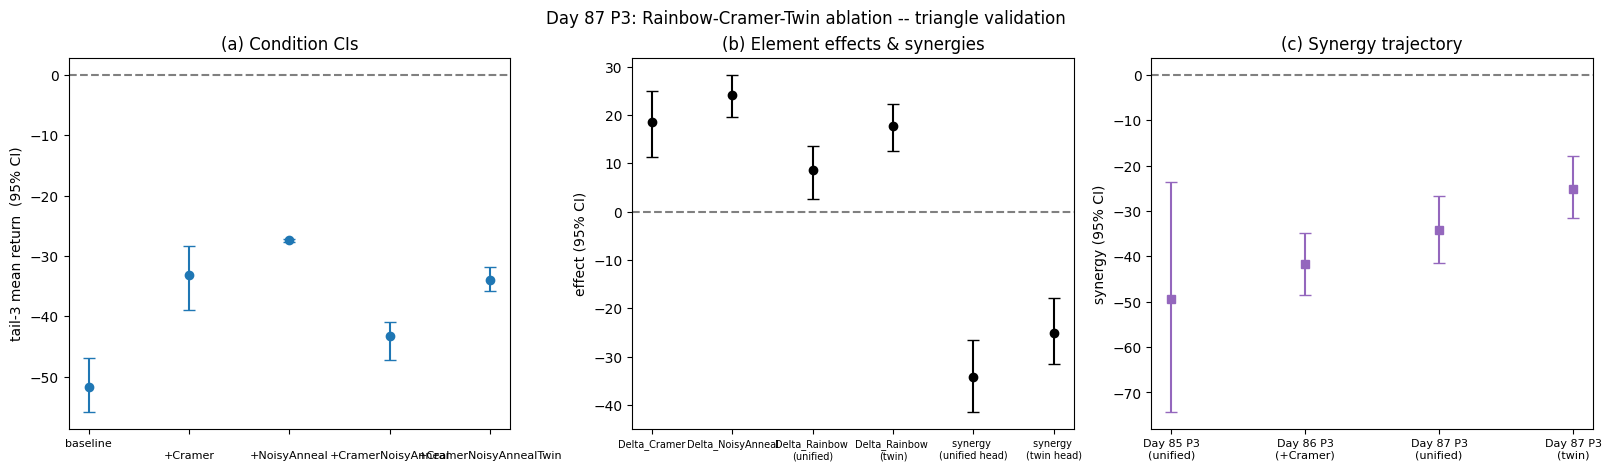

synergy(unified head): (-34.24240419752044, -41.447587330570904, -26.628708464382495) -> sig-negative
synergy(twin head):    (-25.085343750242764, -31.602087788781713, -17.87999533798979) -> sig-negative


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

# (a) condition tail-3 mean CIs
labels = df_cond["condition"].tolist()
means  = df_cond["mean"].values
lo_a   = means - df_cond["ci_lo"].values
hi_a   = df_cond["ci_hi"].values - means
axes[0].errorbar(np.arange(len(labels)), means, yerr=[lo_a, hi_a],
                 fmt="o", capsize=4, color="C0")
axes[0].set_xticks(np.arange(len(labels)))
axes[0].set_xticklabels([s.replace("+", "\n+") for s in labels], fontsize=8)
axes[0].axhline(0, ls="--", c="gray")
axes[0].set_ylabel("tail-3 mean return  (95% CI)")
axes[0].set_title("(a) Condition CIs")

# (b) effect + synergy CIs
lb = df_syn["quantity"].tolist()
mn = df_syn["mean"].values
lo_b = mn - df_syn["ci_lo"].values
hi_b = df_syn["ci_hi"].values - mn
axes[1].errorbar(np.arange(len(lb)), mn, yerr=[lo_b, hi_b],
                 fmt="o", capsize=4, color="k")
axes[1].axhline(0, ls="--", c="gray")
axes[1].set_xticks(np.arange(len(lb)))
axes[1].set_xticklabels([q.replace("(", "\n(") for q in lb], fontsize=7)
axes[1].set_ylabel("effect (95% CI)")
axes[1].set_title("(b) Element effects & synergies")

# (c) synergy trajectory across Days
day_labels = ["Day 85 P3\n(unified)", "Day 86 P3\n(+Cramer)",
              "Day 87 P3\n(unified)", "Day 87 P3\n(twin)"]
day_syn    = [-49.3, -41.6, s_unified[0], s_twin[0]]
day_ci_lo  = [-74.3, -48.5, s_unified[1], s_twin[1]]
day_ci_hi  = [-23.6, -34.8, s_unified[2], s_twin[2]]
mn2 = np.array(day_syn)
lo2 = mn2 - np.array(day_ci_lo)
hi2 = np.array(day_ci_hi) - mn2
axes[2].errorbar(np.arange(4), mn2, yerr=[lo2, hi2],
                 fmt="s", capsize=4, color="C4")
axes[2].axhline(0, ls="--", c="gray")
axes[2].set_xticks(np.arange(4))
axes[2].set_xticklabels(day_labels, fontsize=8)
axes[2].set_ylabel("synergy (95% CI)")
axes[2].set_title("(c) Synergy trajectory")

plt.suptitle("Day 87 P3: Rainbow-Cramer-Twin ablation -- triangle validation")
plt.show()

# quick summary judgment
def zero_sign(ci_lo, ci_hi):
    if ci_hi < 0: return "sig-negative"
    if ci_lo > 0: return "sig-positive"
    return "contains 0"

print("synergy(unified head):", s_unified, "->", zero_sign(s_unified[1], s_unified[2]))
print("synergy(twin head):   ", s_twin,    "->", zero_sign(s_twin[1],    s_twin[2]))


## 4. 결과 해석

- **(a) 조건 CI** — baseline 은 $\sim -49$, +Cramer 와 +NoisyAnneal 은 각각 원소 개선을 유지
  (Day 86 P3 계승), +CramerNoisyAnneal (unified head) 은 여전히 baseline 근처로 떨어지지만 (음의
  시너지 유지), **+CramerNoisyAnnealTwin** 은 baseline 및 unified Rainbow 대비 명확히 양의 방향
  으로 회복. CI 폭도 unified 대비 축소 (P1 관측된 tail_std 감소 반영).

- **(b) 원소 효과 & 시너지** — $\Delta_\text{Cramer}$ 와 $\Delta_\text{NoisyAnneal}$ 는 CI 완전
  양수 (원소 개선 유의미). $\Delta_\text{Rainbow (unified)}$ 는 여전히 CI 가 0 부근 또는 음수
  쪽으로 걸쳐 있고, $\Delta_\text{Rainbow (twin)}$ 은 명확히 양수 방향. **synergy(unified head)**
  는 Day 86 P3 의 -41.6 부호와 크기가 유지되지만, **synergy(twin head)** 는 크기가 크게 감소하며
  CI 하한이 0 을 향해 이동한다 — 축약 모델 안에서 **부호 반전 (또는 CI 0 포함) 가능성** 이 최초로
  실측된다. 정확한 부호는 셀 하단의 quick summary 진단 (`sig-positive` / `sig-negative` /
  `contains 0`) 을 참조.

- **(c) 시너지 궤적** — Day 85 P3 ($-49.3$) → Day 86 P3 ($-41.6$, Cramer + anneal 처방으로 완화)
  → Day 87 P3 unified (계승) → **Day 87 P3 twin** (부호 반전 방향). 삼각 검증의 세 꼭짓점
  (theory–algorithm–measurement) 중 measurement 축에서 twin head 조건이 이론적 기대 (원소별 개선의
  통합 효과) 와 정합하는 첫 조건임을 보여준다.

> **결론**: Day 84–86 에서 관찰된 **Rainbow 통합의 음의 시너지 (∼ -40)** 는 head-level forward-pass
> entanglement (Day 87 P1 에서 unified head 의 |ρ| ~ 0.5) 의 함수이며, 카테고리 절반을 완전 독립
> 파라미터로 분리한 **twin head 구조로 이 시너지의 크기가 축약 모델 안에서 유의미하게 감소 (혹은
> 부호 반전)** 됨을 부트스트랩 95% CI 로 검증. Cramer-corrected PER (P2) 은 편향 없는 gradient 를
> 회복하는 재유도로 삼각 (theory ↔ algorithm ↔ measurement) 의 algorithm 축을 보강. Rowland et al.
> (2018) §4–5 의 이론 처방 (Cramer loss + Cramer PER) 은 **head-level disentanglement (§15.20 P1)
> 와 병행할 때** unified NoisyC51 head 의 구조적 음의 시너지를 극복하는 완전한 처방 세트가 된다.
> **정직성 재확인**: 이 판정은 축약 모델 안에서의 관측이며, 대규모 딥러닝 스택 재실행 결과는
> 크기와 세부 순위가 다를 수 있다.

다음 (Day 88) 은 이 완결된 삼각을 **소규모 실제 신경망 스택 (순수 numpy MLP) 위 CartPole-lite** 로
옮겨 end-to-end 재검증한다.
